
# <span style="color:rgb(213,80,0)">ROZWIĄZYWANIE UKŁADÓW RÓWNAŃ LINIOWYCH</span>

## Postać kanoniczna układu równań liniowych

Do przedstawienia postaci kanonicznej posłużymy się biblioteką sympy do obliczeń symbolicznych oraz numpy do obliczeń numerycznych.

In [1]:
import numpy as np          # odpowida za numeryczne operacje na wektorach i macierzach
from sympy import symbols, Eq, Matrix, cos, sin, pi, simplify  # biblioteka symboliczna

# Najpierw zdefiniujmy, które zmienne będą interpretowane jako zmienne symboliczne
x, y, z = symbols('x y z')   # są to zmienne układu równań 3x3


$$\left\lbrace \begin{array}{l} 2x+y+z=2\\ -x+y-z=3\\ x+2y+3z=-10 \end{array}\right.$$

In [2]:
# Zdefiniujmy trzy przykładowe równania:
row1 = Eq(2*x + y + z, 2)
row2 = Eq(-x + y - z, 3)
row3 = Eq(x + 2*y + 3*z, -10)

# Pod zmienną row(x) kryje się teraz obiekt opisujący równanie np.
row1

Eq(2*x + y + z, 2)

In [3]:
# Przekształćmy taki układ równań do postaci kanonicznej

# W efekcie otrzymamy macierz A i wektor b kanonicznej postaci układu równań

A = Matrix([
    [2, 1, 1],
    [-1, 1, -1],
    [1, 2, 3]
])

A

Matrix([
[ 2, 1,  1],
[-1, 1, -1],
[ 1, 2,  3]])

In [4]:
b = Matrix([2, 3, -10])
b

Matrix([
[  2],
[  3],
[-10]])

In [5]:
# Taki układ równań możemy rozwiązać metodą numeryczną na podstawie postaci kanonicznej

x = A.LUsolve(b)
x

Matrix([
[ 3],
[ 1],
[-5]])


<center>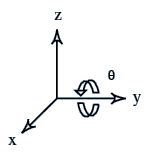</center>


Spróbujmy przyjrzeć się przedstawionemu przykładowi:*Punkt w przestrzeni możemy potraktować jako system współrzędnych. Zgodnie z logiką stosowania macierzy, obrót punktu wokół osi OY układu współrzędnych o kąt Θ można opisać macierzą:*$$A=\left[ \begin{array}{ccc} \cos\left(\theta\right) & 0 & -\sin\left(\theta\right)\\ 0 & 1 & 0\\ \sin\left(\theta\right) & 0 & \cos\left(\theta\right) \end{array}\right]$$Spróbujmy przeprowadzić analizę tego przykładu. Powiedzmy, że nasze znane położenie punktu po obrocie to \(\left[1,1,1\right]\), nasz problem zapisujemy tak:$$\left[ \begin{array}{ccc} \cos\left(\theta\right) & 0 & -\sin\left(\theta\right)\\ 0 & 1 & 0\\ \sin\left(\theta\right) & 0 & \cos\left(\theta\right) \end{array}\right] \left[ \begin{array}{c} x\\ y\\ z \end{array}\right] =\left[ \begin{array}{c} 1\\ 1\\ 1 \end{array}\right]$$co odpowiada takiemu układowi równań:$$\left\lbrace \begin{array}{l} \cos \left(\theta \right)x-\sin \left(\theta \right)z=1\\ y=1\\ \sin \left(\theta \right)\;x+\cos \left(\theta \right)z=1 \end{array}\right.$$

In [6]:
# Wprowadźmy o (θ) jako oznaczenie kąta (w stopniach)
o = symbols('o')

# Nasza macierz układu równań może być zapisana symbolicznie:
# Uwaga: sympy używa radianów, więc cos(o°) = cos(o·π/180)
A = Matrix([
    [cos(o*pi/180), 0, -sin(o*pi/180)],
    [0,             1,  0             ],
    [sin(o*pi/180), 0,  cos(o*pi/180)]
])
b = Matrix([1, 1, 1])

# Przyjmijmy, że o = 60 stopni (π/3 radianów)
Asub = A.subs(o, 60)

# Rozwiążmy taki układ (symbolicznie):
x_symbolic = simplify(A.LUsolve(b))
x_symbolic

Matrix([
[sqrt(2)*sin(pi*(o/180 + 1/4))],
[                            1],
[sqrt(2)*cos(pi*(o/180 + 1/4))]])

In [7]:
x_numeric = Asub.LUsolve(b)
x_numeric

# Wersja dziesiętna (dokładność 4 miejsca po przecinku):
x_decimal = Matrix([float(val.evalf(4)) for val in x_numeric])
x_decimal

Matrix([
[  1.36602783203125],
[               1.0],
[-0.366024017333984]])

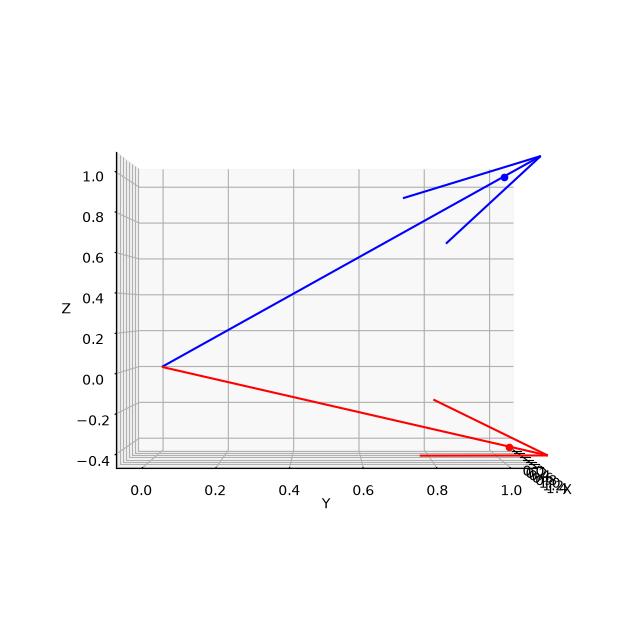

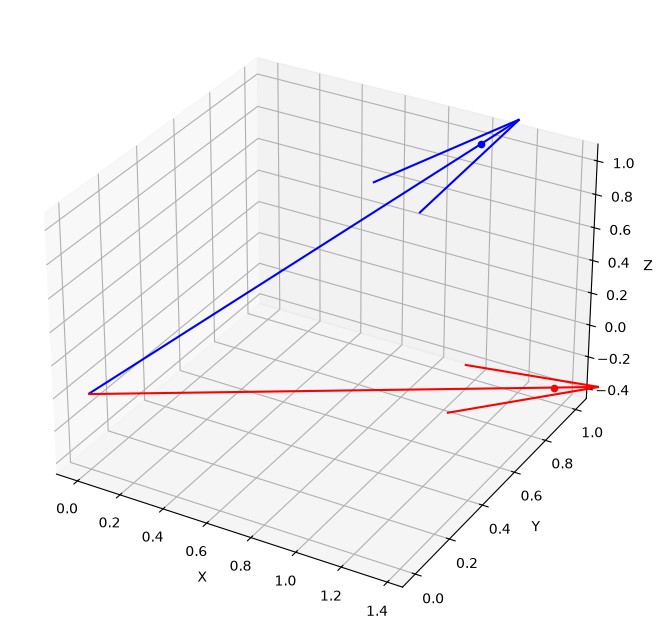

In [8]:
import matplotlib.pyplot as plt   # podstawowa biblioteka do rysowania rysunków matematycznych

def rysujPunkty3D(symbolicPoint, numericPoint):

    # konwersja zmiennej symbolicznej do numerycznej
    localNumeric1 = [float(val) for val in symbolicPoint]
    localNumeric2 = [float(val) for val in numericPoint]

    # Rysowanie 3D - widok z góry
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(localNumeric1[0], localNumeric1[1], localNumeric1[2], color='red', marker='o')
    ax.scatter(localNumeric2[0], localNumeric2[1], localNumeric2[2], color='blue', marker='o')
    ax.grid(True)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.view_init(elev=0, azim=0)
    # Wektory (strzały od początku układu)
    scale = 1.1
    ax.quiver(0, 0, 0, scale*localNumeric2[0], scale*localNumeric2[1], scale*localNumeric2[2], color='blue')
    ax.quiver(0, 0, 0, scale*localNumeric1[0], scale*localNumeric1[1], scale*localNumeric1[2], color='red')
    plt.show()

    # Drugi widok 3D (domyślny)
    fig2 = plt.figure(figsize=(8, 8))
    ax2 = fig2.add_subplot(111, projection='3d')
    ax2.scatter(localNumeric1[0], localNumeric1[1], localNumeric1[2], color='red', marker='o')
    ax2.scatter(localNumeric2[0], localNumeric2[1], localNumeric2[2], color='blue', marker='o')
    ax2.grid(True)
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Z')
    ax2.quiver(0, 0, 0, scale*localNumeric2[0], scale*localNumeric2[1], scale*localNumeric2[2], color='blue')
    ax2.quiver(0, 0, 0, scale*localNumeric1[0], scale*localNumeric1[1], scale*localNumeric1[2], color='red')
    plt.show()


rysujPunkty3D(x_numeric, b)


Spróbuj pozmieniać kąty obrotu. Zwróć uwagę, że w przypadku takiego zadania zmianie ulegnie wyłącznie macierz ***A***, ale nie wektor ***b***. Z takim przypadkiem mamy często do czynienia.


## **ZADANIE**

Uzupełnij poniższy skrypt wpisując postać macierzy  ***A*** i wektora ***b*** dla poniższych przykładów tak, aby oddawała ona przedstawione poniżej układy równań, których rozwiązaniem są wektory samych jedynek:


a)


$$\left\lbrace \begin{array}{l} 3a-b+14c=16\\ a+2b+3c=6\\ a-12b-18c=-29 \end{array}\right.$$

b)


$$\left\lbrace \begin{array}{l} 5s=4t+1\\ r-11s+t=s-10\\ 3r+s+3-7t=0 \end{array}\right.$$

In [ ]:
# Zadanie: wpisz swoją implementację macierzy

A = Matrix([
    # wstaw wiersze macierzy A
]);

b = Matrix([
    # wstaw elementy wektora b
]);

# Rozwiązanie układu równań
x = A.LUsolve(b)

# Sprawdzenie poprawności: rozwiązaniem obu układów powinien być wektor samych jedynek
if x.equals(Matrix([1, 1, 1])):
    print("Bardzo dobrze!")
else:
    print("Spróbuj jeszcze raz...")

## Wykorzystywane funkcje

| Funkcja | Opis |
|---------|------|
| `symbols()` | Tworzy zmienne symboliczne |
| `Eq()` | Tworzy obiekt równania |
| `Matrix()` | Tworzy macierz |
| `A.LUsolve(b)` | Rozwiązuje układ równań A*x=b metodą LU |
| `cos()`, `sin()` | Funkcje trygonometryczne (radiany) |
| `subs()` | Podstawia wartość do wyrażenia symbolicznego |
| `rysujPunkty3D()` | Rysuje dwa punkty i wektory w przestrzeni 3D |